In [1]:
import numpy as np 
import matplotlib.pyplot as plt
from scipy.linalg import norm
import pandas as pd
from scipy import stats
from itertools import product

In [2]:
import sys
import os
# Add the parent directory (simcode) to sys.path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from src.dgp import GaussianNetwork, BernoulliNetwork
from src.metrics import TrueRejection, FalseRejection, Rejection, RelativeFrobeniusNorm
from src.methods import RVPermutationTest, FitIndependent
from src.simulation_functions import run_simulation
from src.analyse_functions import aggregate_results

In [17]:
nsim = 100
n = [50, 100, 200, 250]
k = [2, 5]
sigma = [0]
alpha = [0.05]
marginal_z = [stats.beta]
marginal_x = [stats.beta]
marginal_x_params = [{'a': 2, 'b': 5}]
marginal_z_params = [{'a': 2, 'b': 5}]
edge_var = [1, 3, 5]
dgp = [GaussianNetwork, BernoulliNetwork]
methods = [FitIndependent]
metrics = [RelativeFrobeniusNorm(gram_matrix=True)]

rng = np.random.default_rng(1)

param_names = ["dgp", "method", "n", "k", "sigma", "alpha", "marginal_z", "marginal_x", "edge_var", "marginal_x_params", "marginal_z_params"]

# 2. Generate the cartesian product of values
param_values = product(dgp, methods, n, k, sigma, alpha, marginal_z, marginal_x, edge_var, marginal_x_params, marginal_z_params)

# 3. Zip keys with values to create dictionaries
factorial_design = [dict(zip(param_names, v)) for v in param_values]

out = run_simulation(nsim=nsim, metrics=metrics, factorial_design=factorial_design, rng=rng, parallel=True)

Running scenarios: 100%|██████████| 4800/4800 [00:19<00:00, 245.40it/s]


In [19]:
out = pd.DataFrame(out)
out['n'] = out['args'].apply(lambda x: x['n'])
out['k'] = out['args'].apply(lambda x: x['k'])
out['edge_var'] = out['args'].apply(lambda x: x['edge_var'])

out['dgp'] = out['args'].apply(lambda x: str(x['dgp'])[16:].strip('>').strip("'"))

out['RelativeFrobeniusNorm_z'] = out['RelativeFrobeniusNorm'].apply(lambda x: x[1])
out['RelativeFrobeniusNorm_x'] = out['RelativeFrobeniusNorm'].apply(lambda x: x[0])

In [20]:
out_gaussian = out[out['dgp'] == 'GaussianNetwork']
out_bernoulli = out[out['dgp'] == 'BernoulliNetwork']

out_x_gaussian = out_gaussian.drop(columns=['RelativeFrobeniusNorm', 'RelativeFrobeniusNorm_z'])
out_x_bernoulli = out_bernoulli.drop(columns=['RelativeFrobeniusNorm', 'RelativeFrobeniusNorm_z'])

out_z_gaussian = out_gaussian.drop(columns=['RelativeFrobeniusNorm', 'RelativeFrobeniusNorm_x'])
out_z_bernoulli = out_bernoulli.drop(columns=['RelativeFrobeniusNorm', 'RelativeFrobeniusNorm_x'])

In [22]:
agg_out_z_gaussian = aggregate_results(out_z_gaussian, y_axis='RelativeFrobeniusNorm_z', x_axis='n', factors=['edge_var', 'k'])
agg_out_x_gaussian = aggregate_results(out_x_gaussian, y_axis='RelativeFrobeniusNorm_x', x_axis='n', factors=['edge_var', 'k'])
agg_out_x_bernoulli = aggregate_results(out_x_bernoulli, y_axis='RelativeFrobeniusNorm_x', x_axis='n', factors=['edge_var', 'k'])
agg_out_z_bernoulli = aggregate_results(out_z_bernoulli, y_axis='RelativeFrobeniusNorm_z', x_axis='n', factors=['edge_var', 'k'])

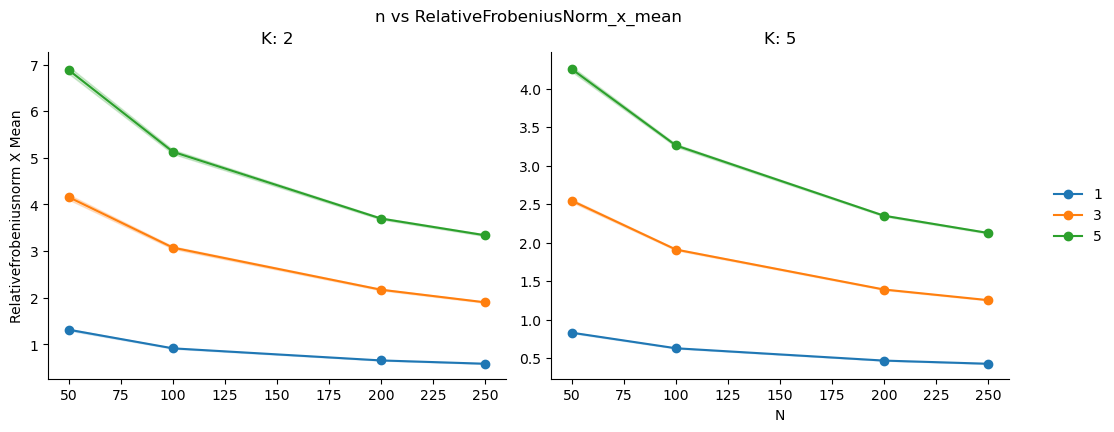

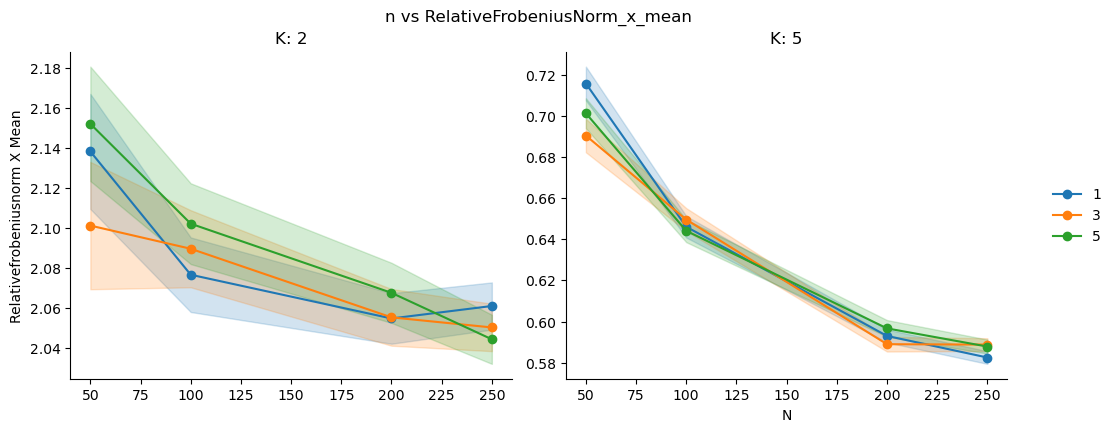

In [24]:
from src.plot_functions import plot_grid, plot_with_bands

plot_grid(
        grouped_stats=agg_out_x_gaussian,
        plotting_function=plot_with_bands,
        x_axis='n',
        y_axis='RelativeFrobeniusNorm_x_mean',
        factors=['edge_var', 'k'],
        height=4,
        se_bands='RelativeFrobeniusNorm_x_sem',
        share_x=True,
        share_y=False
    )

plot_grid(
        grouped_stats=agg_out_x_bernoulli,
        plotting_function=plot_with_bands,
        x_axis='n',
        y_axis='RelativeFrobeniusNorm_x_mean',
        factors=['edge_var', 'k'],
        height=4,
        se_bands='RelativeFrobeniusNorm_x_sem',
        share_x=True,
        share_y=False
    )

In [ ]:
1/0

from src.plot_functions import plot_grid, plot_with_bands

plot_grid(
        grouped_stats=agg_out,
        plotting_function=plot_with_bands,
        x_axis='n',
        y_axis='FalseRejection_mean',
        factors=['edge_var', 'k'],
        height=4,
        se_bands='FalseRejection_sem',
        share_x=True,
        share_y=False
    )

plot_grid(
        grouped_stats=agg_out_true,
        plotting_function=plot_with_bands,
        x_axis='n',
        y_axis='TrueRejection_mean',
        factors=['edge_var', 'k'],
        height=4,
        se_bands='FalseRejection_sem',
        share_x=True,
        share_y=False
    )

ZeroDivisionError: division by zero

In [ ]:
n = 200
k = 5
sigma = 0
rng = np.random.default_rng()

md = GaussianNetwork(n=n, k=k, sigma=sigma, 
                     marginal_z=stats.norm, marginal_x=stats.norm,
                     rng=rng, edge_var=0.5)
A, B, X, Z = md.generate()

rv = RVPermutationTest(npermutations=2000, sigma=sigma, alpha=0.05, rng=rng)
rv.fit(A, B)
rv.get_estimated(), rv.pvalue

(np.False_, np.float64(0.9615))

In [ ]:
rv = RVPermutationTest(npermutations=2000, sigma=sigma, alpha=0.05, rng=rng)
rv.fit(A, B)
rv.get_estimated(), rv.pvalue

(np.False_, np.float64(0.959))

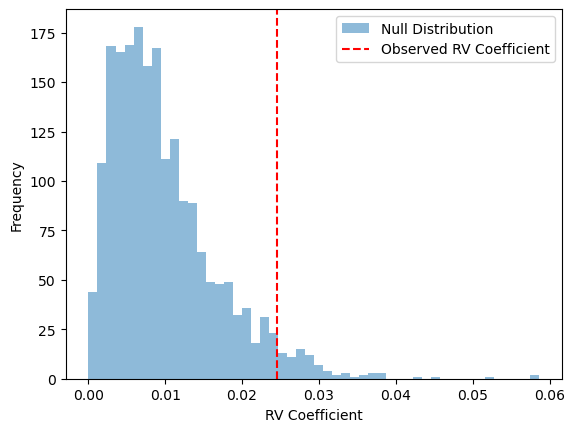

In [ ]:
plt.hist(rv.rv_distr, bins=50, alpha=0.5, label='Null Distribution')
plt.axvline(rv.rv_est, color='red', linestyle='--', label='Observed RV Coefficient')
plt.xlabel('RV Coefficient')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [ ]:
from methods import solve_dependent, objective_function
from metrics import relative_frobenius_norm

rng = np.random.default_rng(1)
n = 100
k = 2
sigma = 0.99
edge_var = 1
niters = 500
delta_reg = 0.309
step_size = 0.5
lambda_reg = 0

md = GaussianNetwork(n=100, k=5, sigma=0.5, 
                     marginal_z=norm, marginal_x=norm,
                     rng=rng, edge_var=1)

A, B, Z, X = md.generate()
M = np.block([[Z@Z.T, X@Z.T], [X@Z.T, X@X.T]])

Ms, sigmas = solve_dependent(A, B, k=k, niters=niters, rng=rng, fit_sigma=True, 
                             sigma=None, delta_reg=delta_reg, step_size=step_size,
                             lambda_reg=0)

errs_M = [relative_frobenius_norm(Ms[i], M) for i in range(len(Ms))]
errs_sigma = [np.abs(np.abs(sigmas[i])- np.abs(sigma)) for i in range(len(sigmas))]

lambda_reg = (2 + delta_reg) * np.sqrt(2 * n)

obj_out = []
for i in range(len(Ms)):
    t = objective_function(n, k, Ms[i], A, B, sigma=sigmas[i], lambda_reg=0)
    obj_out.append(t)

ImportError: cannot import name 'solve_dependent' from 'methods' (/Users/lrcosta/umich/network_independence/simulation_code/methods.py)

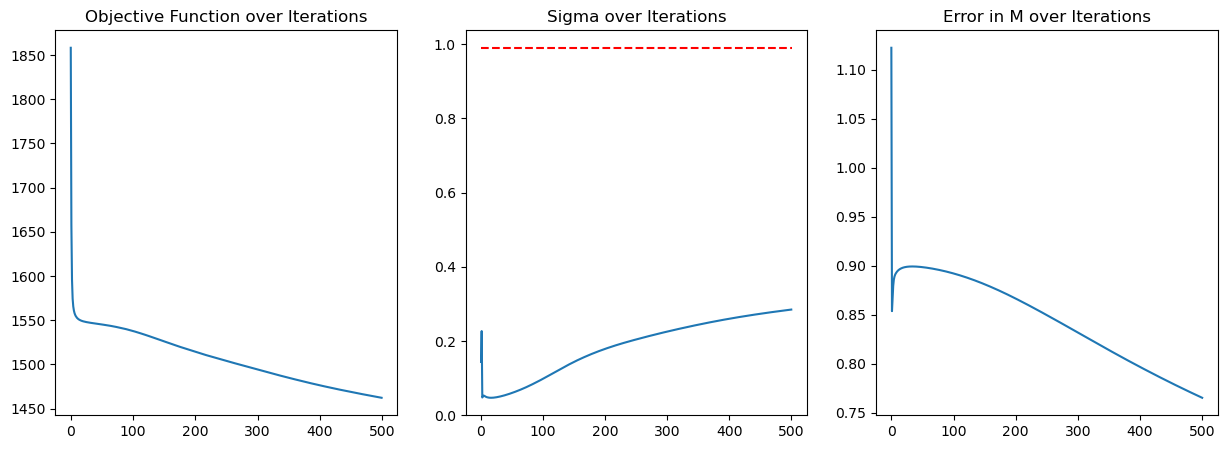

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].set_title('Objective Function over Iterations')
ax[0].plot(obj_out[1:], label='Objective Function')
ax[1].set_title('Sigma over Iterations')
ax[1].plot(sigmas, label='Sigma')
ax[1].hlines(sigma, xmin=0, xmax=len(sigmas), colors='r', linestyles='dashed')
ax[2].set_title('Error in M over Iterations')
ax[2].plot(errs_M, label='Error in M')
#plt.legend()
plt.show()

In [ ]:
np.allclose(X@Z.T, (Z@X.T).T)

True

In [ ]:
from methods import llk_gradient

llk_gradient(M, A, B, sigma, n), llk_gradient(Ms[-1], A, B, sigmas[-1], n)

(array([[107.23551705,  -4.83914024,   2.51291955, ...,   0.        ,
           0.        ,   0.        ],
        [ -4.83914024,  95.04318952,  -1.83911461, ...,   0.        ,
           0.        ,   0.        ],
        [  2.51291955,  -1.83911461,  97.11224029, ...,   0.        ,
           0.        ,   0.        ],
        ...,
        [  0.        ,   0.        ,   0.        , ...,  99.19489524,
           2.26426604,  -1.41099213],
        [  0.        ,   0.        ,   0.        , ...,   2.26426604,
         102.19868057,   5.24081558],
        [  0.        ,   0.        ,   0.        , ...,  -1.41099213,
           5.24081558, 105.88868837]], shape=(100, 100)),
 array([[13.9175947 , -4.43661834,  2.08916819, ...,  0.        ,
          0.        ,  0.        ],
        [-4.43661834,  8.62546279, -0.06030215, ...,  0.        ,
          0.        ,  0.        ],
        [ 2.08916819, -0.06030215,  9.36733759, ...,  0.        ,
          0.        ,  0.        ],
        ...,


In [ ]:
from methods import llk_gradient

llk_gradient(M, A, B, 0.5, n), llk_gradient(Ms[1], A, B, 0.5, n), 

(array([[ 8.48665026, -3.4847402 ,  3.13530843, ...,  0.        ,
          0.        ,  0.        ],
        [-3.4847402 ,  1.17562802,  0.38078356, ...,  0.        ,
          0.        ,  0.        ],
        [ 3.13530843,  0.38078356,  5.46311655, ...,  0.        ,
          0.        ,  0.        ],
        ...,
        [ 0.        ,  0.        ,  0.        , ...,  2.69215026,
         -0.16253323,  4.19429663],
        [ 0.        ,  0.        ,  0.        , ..., -0.16253323,
          3.48081469, -0.11770724],
        [ 0.        ,  0.        ,  0.        , ...,  4.19429663,
         -0.11770724,  5.95740446]], shape=(400, 400)),
 array([[35.33729013,  0.58348053, -0.89072398, ...,  0.        ,
          0.        ,  0.        ],
        [ 0.58348053, 33.2357832 , -0.48087974, ...,  0.        ,
          0.        ,  0.        ],
        [-0.89072398, -0.48087974, 35.10492745, ...,  0.        ,
          0.        ,  0.        ],
        ...,
        [ 0.        ,  0.        ,  

In [ ]:
np.block([[np.zeros_like(M[:n, :n]), M[:n, n:]], [M[n:, :n], np.zeros_like(M[n:, n:])]])

array([[ 0.        ,  0.        ,  0.        , ...,  1.07750578,
        -0.99726528,  1.38248138],
       [ 0.        ,  0.        ,  0.        , ..., -0.04139616,
        -1.5398645 ,  0.79840594],
       [ 0.        ,  0.        ,  0.        , ...,  0.24195064,
        -0.77574286, -1.54581544],
       ...,
       [-0.42702891, -0.50640838,  0.52785894, ...,  0.        ,
         0.        ,  0.        ],
       [ 2.3778416 ,  0.64087085, -0.30974033, ...,  0.        ,
         0.        ,  0.        ],
       [-1.82881448, -0.18211481,  0.4762939 , ...,  0.        ,
         0.        ,  0.        ]], shape=(400, 400))

In [ ]:
objective_function(n, k, np.block([[np.zeros_like(M[:n, :n]), M[:n, n:]], [M[n:, :n], np.zeros_like(M[n:, n:])]]), A, B, sigma=0.1, lambda_reg=lambda_reg)

np.float64(55420.91365582353)

In [ ]:
Ms[-1].sum(), Ms[-2].sum()

(np.float64(7549.85237452929), np.float64(7562.624820287671))

In [ ]:
out_M = out.drop(columns=['err_sigma'])
out_sigma = out.drop(columns=['err_M'])

agg_out_M = aggregate_results(out_M, y_axis='err_M', x_axis='n', factors=['step_size', 'edge_var', 'k'])
agg_out_sigma = aggregate_results(out_sigma, y_axis='err_sigma', x_axis='n', factors=['step_size', 'edge_var', 'k'])

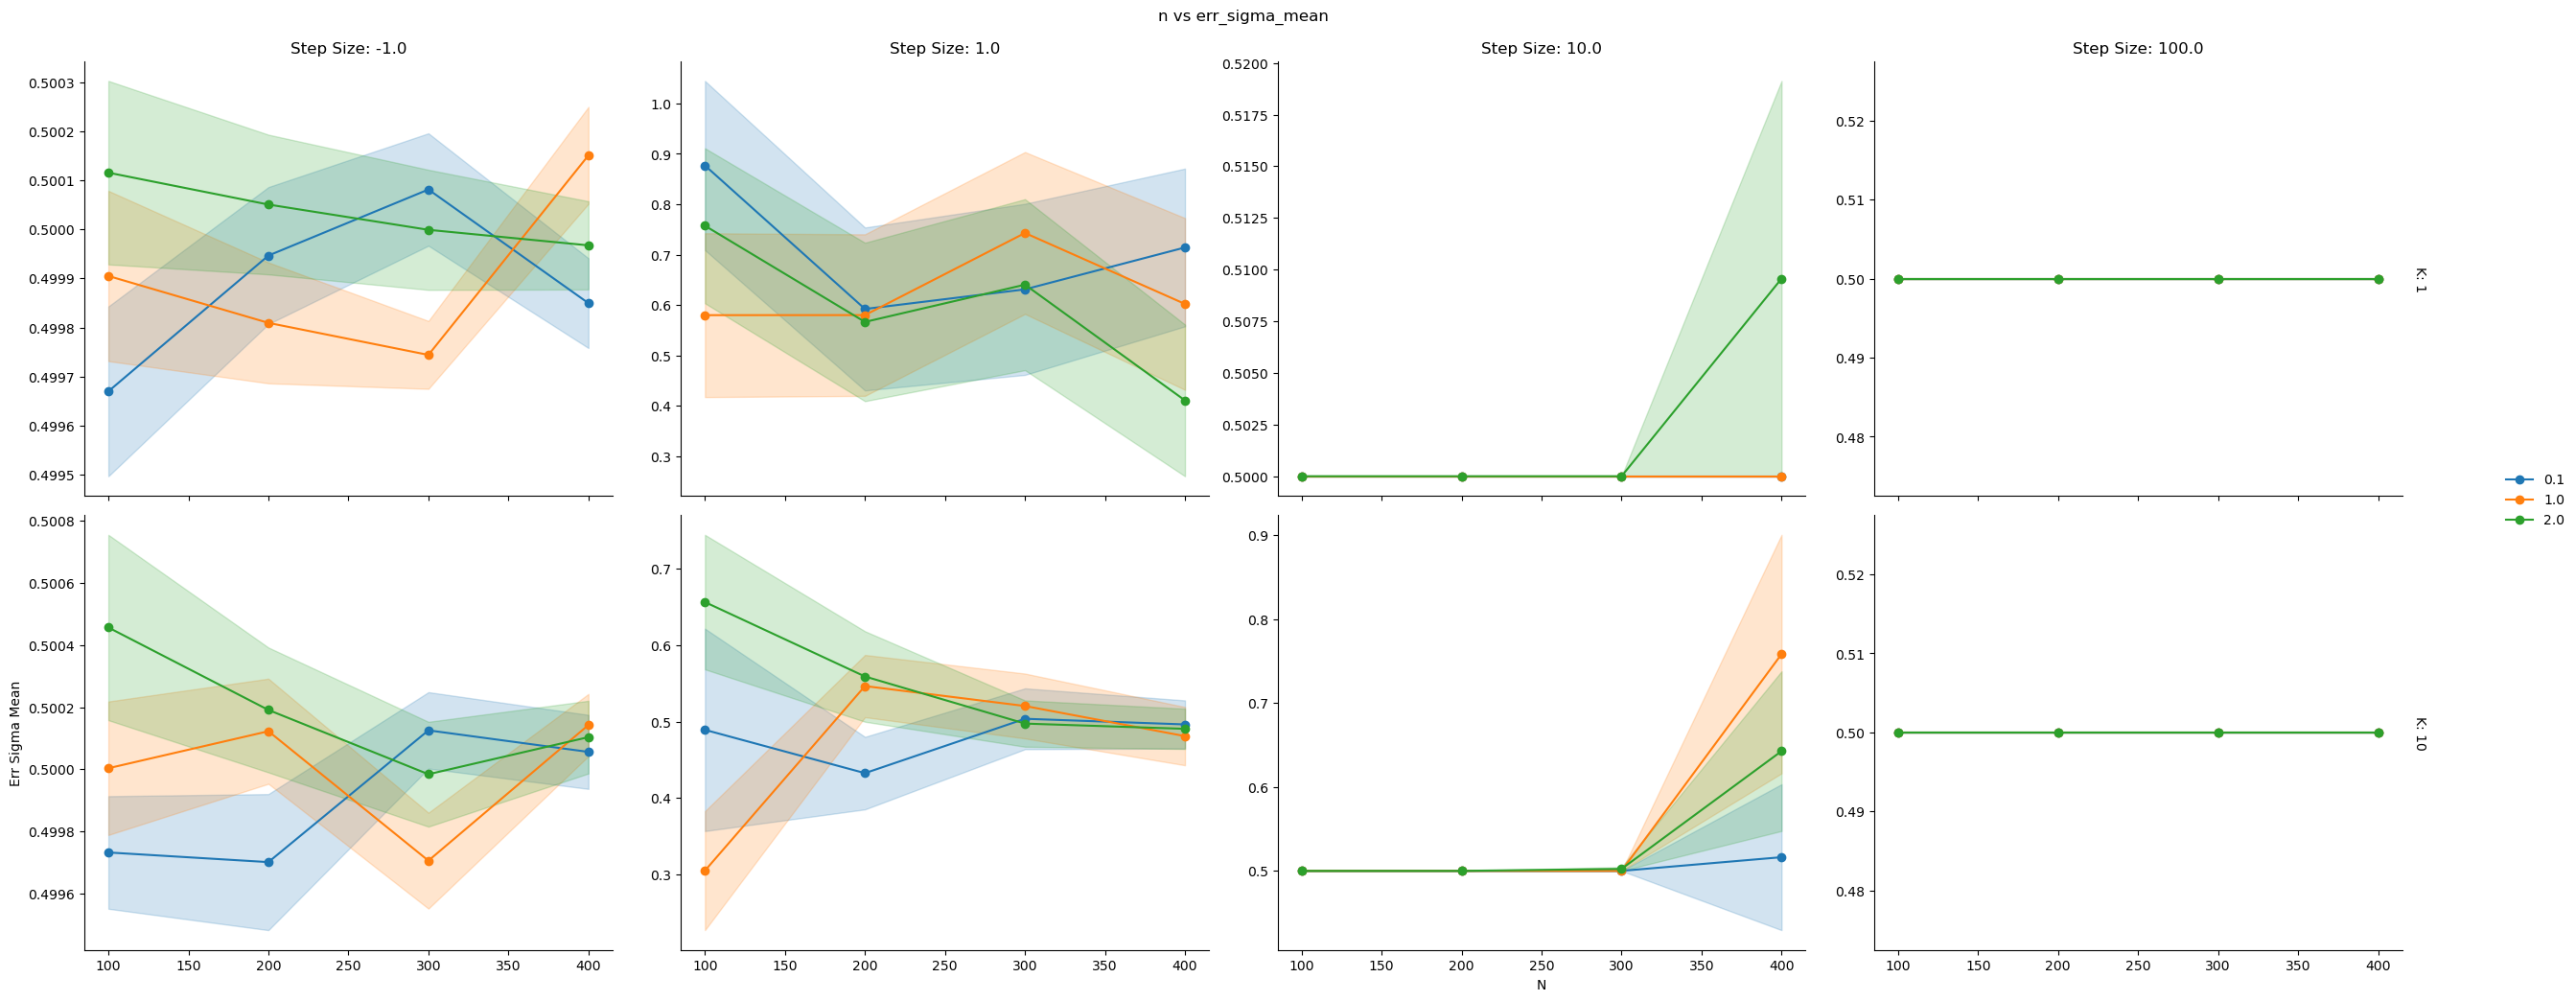

In [ ]:
out_M = out.drop(columns=['err_sigma'])
out_sigma = out.drop(columns=['err_M'])

agg_out_M = aggregate_results(out_M, y_axis='err_M', x_axis='n', factors=['step_size', 'edge_var', 'k'])
agg_out_sigma = aggregate_results(out_sigma, y_axis='err_sigma', x_axis='n', factors=['step_size', 'edge_var', 'k'])

plot_grid(
        grouped_stats=agg_out_sigma,
        plotting_function=plot_with_bands,
        x_axis='n',
        y_axis='err_sigma_mean',
        factors=['edge_var', 'step_size', 'k'],
        height=5,
        se_bands='err_sigma_sem',
        share_x=True,
        share_y=False
    )

In [ ]:
out.groupby('n').mean()[['err_M', 'err_sigma']]

,err_M,err_sigma
n,,
100,249.891910,0.527706
200,250.274400,0.511538
300,248.134223,0.522429
400,248.021194,0.525935


#### Independence test

In [ ]:
rng = np.random.default_rng(1)
n = 50
k = 5
edge_var = 5
sigma = 0

A, B, Z, X = generate_gaussian_data(n, k, sigma, edge_var=edge_var, rng=rng)

Zhat, evals_A = solve_independent(A, k=k)
Xhat, evals_B = solve_independent(B, k=k)
rv_est = rv_coefficient(Zhat, Xhat)
rv_coefficient(A, B), rv_coefficient(Zhat, Xhat), rv_coefficient(Z, X)

(np.float64(0.3578749432547567),
 np.float64(0.11070601134747417),
 np.float64(0.1069607284028805))

In [ ]:
n_perm = 100
rv_distr = []
for i in range(n_perm):
    perm = rng.permutation(n)
    X_perm = X[perm, :]
    rv_perm = rv_coefficient(X_perm, Z)
    rv_distr.append(rv_perm)

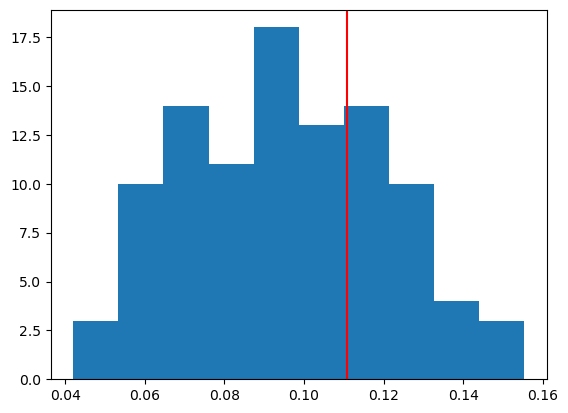

In [ ]:
fig, ax = plt.subplots()
ax.hist(rv_distr)
ax.axvline(rv_est, color='red')
plt.show()